# DSAI LAB 6 - Proshita Agarwal

### PART 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def Slope(dataset, plot=False):
    n = len(dataset)
    sample = np.random.choice(dataset, size=n, replace=True)
    x = np.arange(1, n+1)
    slope, intercept = np.polyfit(x, sample, 1)
    
    # Only plot if requested
    if plot:
        plt.plot(x, sample, 'o', alpha=0.4)
        plt.plot(x, slope*x + intercept, '-', color='red', alpha=0.6)
        plt.title("Line of Best Fit for One Bootstrap Sample")
        plt.show()
    
    return slope

In [3]:
# Dataset of integers from 75 to 90
dataset = np.arange(75, 91)

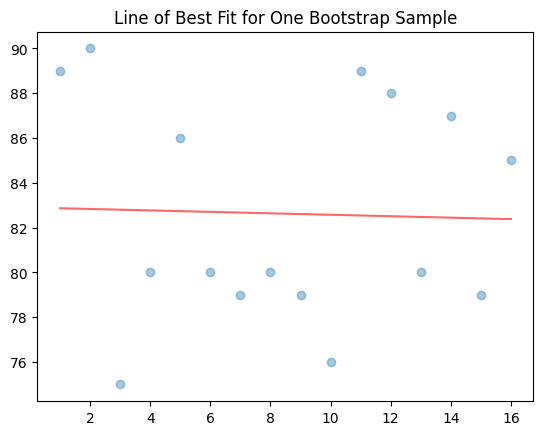

In [4]:
# Show one example plot
_ = Slope(dataset, plot=True)

In [5]:
# Collect slopes without plotting
slopes = [Slope(dataset) for _ in range(1000)]

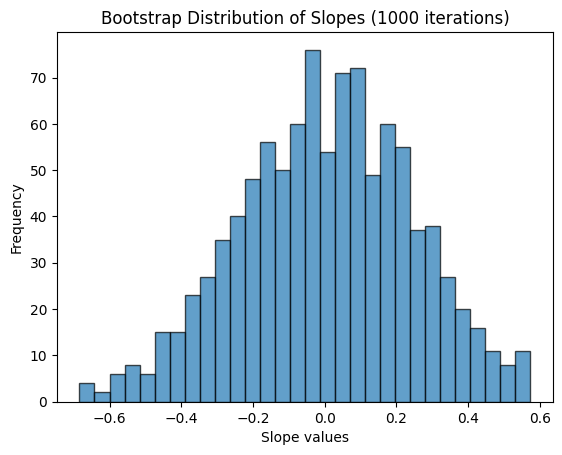

Mean of slopes: 0.0036485294117674484
Standard deviation of slopes: 0.24147471533604978


In [6]:
plt.hist(slopes, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Slope values")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Slopes (1000 iterations)")
plt.show()

print("Mean of slopes:", np.mean(slopes))
print("Standard deviation of slopes:", np.std(slopes))

### Discussion of Results (Bootstrap Distribution of Slopes)

From the histogram of slopes obtained through bootstrapping, we observe that the slope values are not identical across samples, even though they all came from the same dataset (integers 75–90). This variability happens because each bootstrap sample is drawn with replacement, meaning some values are repeated and some are left out in each resample.

The distribution of slopes gives us insight into the uncertainty and variability of the slope estimate. The mean of the bootstrap slopes is close to the “true” slope we would obtain from the original dataset, but the spread (standard deviation) tells us how sensitive the slope is to changes in the sample.

In practice, this means:
- The slope we calculate from a single dataset is just one estimate.
- Bootstrapping shows us how much that estimate could change if we had drawn different samples from the same population.
- A narrower histogram (low variability) indicates more reliable slope estimates, while a wider histogram (high variability) shows greater uncertainty.

Thus, bootstrapping provides a way to quantify confidence in our statistical estimates, without needing additional real-world data.

### Part 2

In [7]:
import pandas as pd

In [9]:
df = pd.read_csv("marketing_dataset.csv")

X = df["Advertising Spend"].values
y = df["Sales Revenue"].values

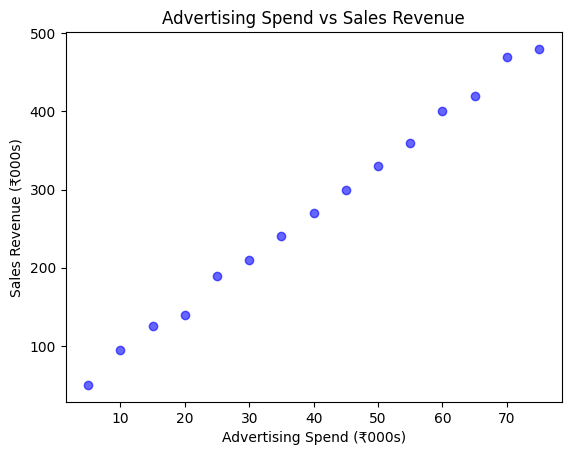

In [10]:
# Step 1: Scatter plot of data points
plt.scatter(X, y, color="blue", alpha=0.6)
plt.xlabel("Advertising Spend (₹000s)")
plt.ylabel("Sales Revenue (₹000s)")
plt.title("Advertising Spend vs Sales Revenue")
plt.show()

In [11]:
# Step 2
slope, intercept = np.polyfit(X, y, 1)

print("Slope (β1):", slope)
print("Intercept (β0):", intercept)

Slope (β1): 6.13214285714286
Intercept (β0): 26.714285714285722


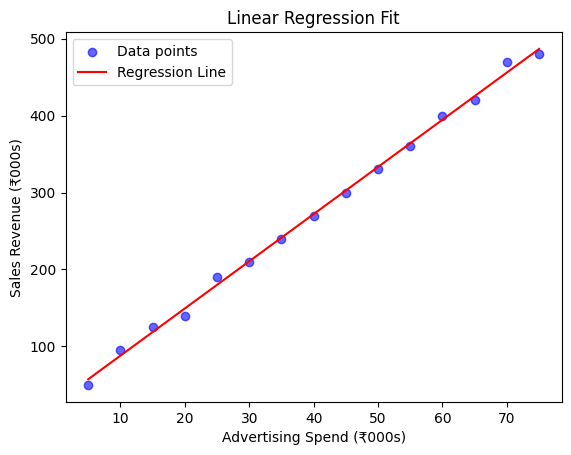

In [ ]:
# Step 3: Plotting regression line
plt.scatter(X, y, color="blue", alpha=0.6, label="Data points")
plt.plot(X, slope*X + intercept, color="red", label="Regression Line")
plt.xlabel("Advertising Spend")
plt.ylabel("Sales Revenue")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

In [13]:
# Step 4: Calculating predicted values
y_pred = slope*X + intercept

# Step 5: SSE
errors = y - y_pred
SSE = np.sum(errors**2)

print("Residual Sum of Errors (SSE):", SSE)

Residual Sum of Errors (SSE): 667.767857142858


### Discussion of Results (Linear Regression)

The scatter plot shows a generally upward trend: as Advertising Spend increases, Sales Revenue also tends to rise.  
The fitted regression line quantifies this relationship. The slope (β1) indicates how much Sales Revenue increases, on average, for each additional unit of Advertising Spend (in thousands of INR). The intercept (β0) represents the baseline Sales Revenue when Advertising Spend is zero.

The Residual Sum of Errors (SSE) measures the difference between the actual values and the predicted values from the regression line. A smaller SSE indicates that the regression line closely fits the data points, while a larger SSE suggests more deviation.

Overall, the results highlight a linear dependency between Advertising Spend and Sales Revenue: higher advertising investments are associated with higher sales outcomes, which makes intuitive business sense.